# Описание файла

В данном ноутбуке мы сосредоточимся на повышении качества базовых моделей — для этого проведём дополнительную обработку данных. Рассмотрим два возможных подхода.

* Тестировать каждое преобразование отдельно и сравнивать с бейслайном, затем выбрать только лучшие и скомбинировать их;
* Поочередно применять удачные преобразования, сравнивая результат каждого нового преобразования с результатом предыдущего (итеративный подход).

Здесь мы будем использовать первый подход

# Импорт основных библиотек

In [1]:
# импорт модулей/библиотек для обработки данных
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
from my_def_and_plot import *
from plots import *
import random

In [2]:
# импорт необходимого окружения для визуализации
# отключим предупреждения Anaconda
import warnings
warnings.simplefilter('ignore')

# будем отображать графики прямо в jupyter'e
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
#графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 

#увеличим дефолтный размер графиков
from pylab import rcParams
rcParams['figure.figsize'] = 8, 5
import pandas as pd

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

In [4]:
df = pd.read_csv('bank.csv')

# 0. Модель до предобработки

In [5]:
# разбиваем признаковое описание на входные признаки и целевой признак
X, y = divide_data(df, 'deposit')
# явно указываем категориальные признаки
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
# кодируем категориальные признаки
X_encoded_0 = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [6]:
# сохраним все бейслайн модели в виде списка для удобства
models = [
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4)),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED)),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED))
]

In [7]:
# используем 5-блочную кросс-валидацию, учитывающую распределение таргета при разбиении
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

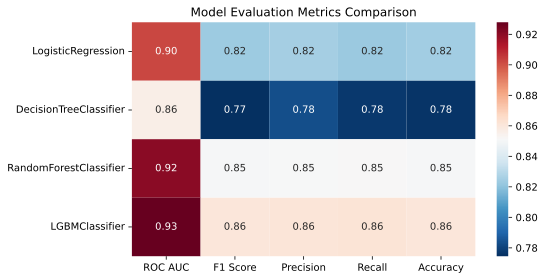

In [8]:
initial_metrics_0 = train_evaluate_models_cv(
    models=models,
    X=X_encoded_0,
    y=y,
    cv=cv,
    seed=SEED
)

# 1. Предобработка

Необходимо сделать преобразования, которые сделали в *baseline*...

In [9]:
# создадим независимую копию исходного DataFrame df
df_preprocessed = df.copy()

По признаку **balance**:

In [10]:
# введем список количественных и качественных признаков (используем списковое включение)

numerical_features = [x for x in df.columns if pd.api.types.is_numeric_dtype(df[x])]

categorical_features = [x for x in df.columns if not pd.api.types.is_numeric_dtype(df[x])]

In [11]:
# создание новых признаков
df_preprocessed['has_debt'] = (df_preprocessed['balance'] < 0).astype(int)
df_preprocessed['debt_amount'] = df_preprocessed['balance'].clip(upper=0).abs()      # размер долга
df_preprocessed['positive_balance'] = df_preprocessed['balance'].clip(lower=0)       # только положительный баланс

# Логарифмируем только положительные части (там, где есть смысл)
df_preprocessed['log_positive_balance'] = np.log1p(df_preprocessed['positive_balance'])
df_preprocessed['log_debt_amount'] = np.log1p(df_preprocessed['debt_amount'])

In [12]:
# добавляем введенные признаки в список numerical_features

numerical_features = numerical_features + [
    'has_debt',
    'debt_amount',
    'positive_balance',
    'log_positive_balance',
    'log_debt_amount'
]

По признаку **duration**:

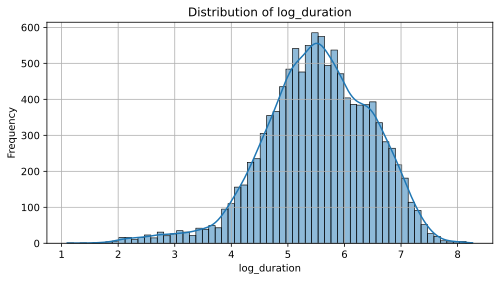

In [13]:
# логарифмирование признака 
df_preprocessed['log_duration'] = np.log1p(df_preprocessed['duration'])
# вывод гистограммы
plot_hist_numeric(df_preprocessed, 'log_duration')

По признаку **age**:

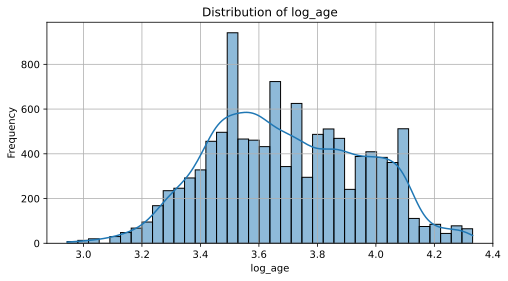

In [14]:
# удаляем выбросы
df_preprocessed= df_preprocessed[df_preprocessed['age']<=75]
# логарифмирование признака 
df_preprocessed['log_age'] = np.log1p(df_preprocessed['age'])
# вывод гистограммы
plot_hist_numeric(df_preprocessed, 'log_age')

По признаку **campaign**:

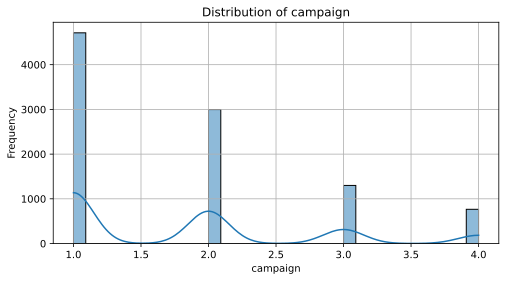

In [15]:
# удалим клиентов, с которыми контактировали более 4 раз за кампанию 

df_preprocessed = df_preprocessed[df_preprocessed['campaign']<=4]
# вывод гистограммы
plot_hist_numeric(df_preprocessed, 'campaign')


По признаку **job**:

In [16]:
# проведем объединение малых групп клиентов в подгруппу outher

job_counts = df_preprocessed['job'].value_counts(normalize = True) # находим доли специальностей клиентов

list_smol_job = job_counts[job_counts <= 0.06].index.tolist() # список названий специальностей с маленькой долей

df_preprocessed.loc[df_preprocessed['job'].isin(list_smol_job), 'job'] = 'other' # замена

df_preprocessed['job'].value_counts(normalize = True) # прверка замены

job
management     0.229793
other          0.221813
blue-collar    0.177000
technician     0.165439
admin.         0.122775
services       0.083180
Name: proportion, dtype: float64

По признаку **ededucation**:

In [17]:
# в признаке ededucation 'unknown' надо объединить с 'primary'
df_preprocessed['education'] = df_preprocessed['education'].replace('unknown', 'primary')

df_preprocessed['education'].value_counts(normalize = True) # прверка замены

education
secondary    0.497238
tertiary     0.333947
primary      0.168815
Name: proportion, dtype: float64

По признаку **default**:

In [18]:
# удаление признака 'default'
df_preprocessed = df_preprocessed.drop('default', axis=1)

In [19]:
# разбиваем признаковое описание на входные признаки и целевой признак
X_1, y_1 = divide_data(df_preprocessed, 'deposit')
# явно указываем категориальные признаки
cat_cols = X_1.select_dtypes(include=['object', 'category']).columns.tolist()
# кодируем категориальные признаки
X_encoded = pd.get_dummies(X_1, columns=cat_cols, drop_first=True)

# 2. Валидационный подбор

In [20]:
# сохраним все бейслайн модели в виде списка для удобства
models = [
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4)),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED)),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED))
]

In [21]:
# используем 5-блочную кросс-валидацию, учитывающую распределение таргета при разбиении
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

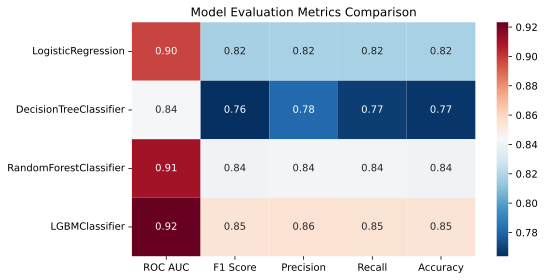

In [22]:
initial_metrics = train_evaluate_models_cv(
    models=models,
    X=X_encoded,
    y=y_1,
    cv=cv,
    seed=SEED
)


(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.005346 -0.006174  -0.007388 -0.005552 -0.007019
 DecisionTreeClassifier -0.013810 -0.010668  -0.002103 -0.009112 -0.009706
 RandomForestClassifier -0.009443 -0.010110  -0.009614 -0.010965 -0.010133
 LGBMClassifier         -0.004649 -0.006360  -0.005339 -0.006985 -0.006393)

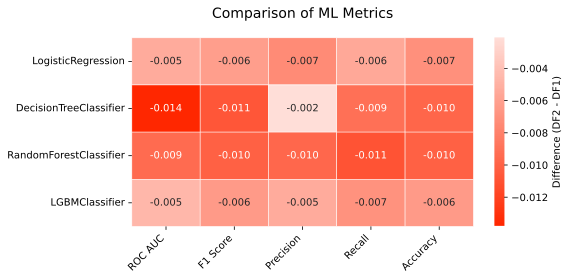

In [23]:
compare_metrics_heatmap(initial_metrics_0, initial_metrics)

Добавление новых признаков привело к систематическому ухудшению качества моделей по всем ключевым метрикам. Падение наблюдается как для линейных методов (LogisticRegression), так и для ансамблей (RandomForest, LGBM) и даже для одиночного дерева. Это говорит о том, что новые признаки скорее ухудшают обобщающую способность, а не улучшают её.

# 3. Преобразования данных и feature engineering

## 3.1 С удалением признаков, которые прошли логарифмирование 

In [24]:
# копирование входных признаков
X_log_delete = X_encoded.copy()   

In [25]:
# удаление признаков, которые прошли логарифмирование
X_log_delete.drop(['duration', 'positive_balance', 'debt_amount', 'age'], axis=1, inplace=True)


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

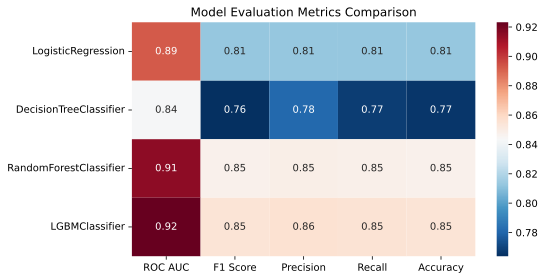

In [26]:
log_delete_metrics = train_evaluate_models_cv(
    models=models,
    X=X_log_delete,
    y=y_1,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.004973 -0.004768  -0.004681 -0.004625 -0.004809
 DecisionTreeClassifier  0.000000  0.000000   0.000000  0.000000  0.000000
 RandomForestClassifier  0.003967  0.007454   0.007863  0.007568  0.007469
 LGBMClassifier         -0.000029  0.000000   0.000000  0.000000  0.000000)

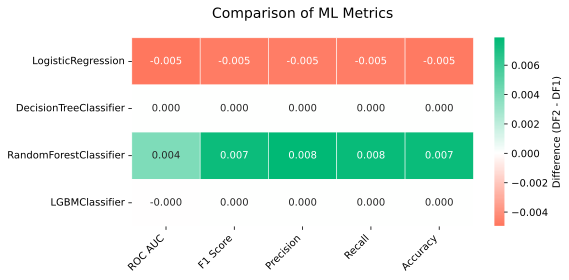

In [27]:
compare_metrics_heatmap(initial_metrics, log_delete_metrics)

* **LogisticRegression**. Наблюдается незначительное снижение всех метрик — в среднем примерно на 0,005. Это свидетельствует о том, что удалённые признаки несли полезную информацию для линейной модели либо, как минимум, не ухудшали её предсказательную способность;
* **DecisionTreeClassifier**. Значения дельты по всем метрикам равны нулю. Отсутствие изменений указывает на то, что в текущей конфигурации дерево решений не использовало удалённые признаки в разбиениях либо их влияние оказалось скомпенсированным иными правилами разделения;
* **RandomForestClassifier**. Зафиксирован рост всех метрик, наиболее выраженный для F1‑score, Precision и Recall (прирост на уровне 0,007–0,008). Улучшение результатов позволяет предположить, что удаление признаков позволило снизить уровень шума или исключить слабоинформативные переменные — в итоге ансамбль деревьев стал демонстрировать более стабильное обобщение;
* **LGBMClassifier**. Модель продемонстрировала высокую устойчивость к изменению набора признаков: значимые отклонения отсутствуют, отмечен лишь минимальный спад ROC AUC на уровне 2.9*10^(-5). Это подтверждает робастность градиентного бустинга к модификациям признакового пространства в данном случае.

## 3.2 Создание нового признака

In [28]:
# копирование входных признаков
X_new_features = X_1.copy()

In [29]:
# balance_per_age (баланс на год жизни)
X_new_features['balance_per_age'] = X_new_features['balance'] / (X_new_features['age'] + 1)
# удаление 'balance' и 'age'
X_new_features.drop(['balance', 'age'], axis=1, inplace=True)

# has_any_credit: бинарный флаг, если у клиента есть хотя бы один кредит (жилищный или личный)
X_new_features['has_any_credit'] = (X_new_features['housing'] == 'yes') | (X_new_features['loan'] == 'yes')
# total_debt_flags - счётчик кредитов (0, 1 или 2)
X_new_features['total_debt_flags'] = X_new_features['housing'].eq('yes').astype(int) + X_new_features['loan'].eq('yes').astype(int)
# удаление 'housing' и 'loan'
X_new_features.drop(['housing', 'loan'], axis=1, inplace=True)

# contact_recency - «свежесть» контакта. Если pdays == -1 (не было контакта) cnfdbv  большое число (например, 999)
X_new_features['contact_recency'] = X_new_features['pdays'].replace(-1, 999)

In [30]:
# явно указываем категориальные признаки
cat_cols = X_1.select_dtypes(include=['object', 'category']).columns.tolist()
# кодируем категориальные признаки
X_new_features_encoded = pd.get_dummies(X_1, columns=cat_cols, drop_first=True)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

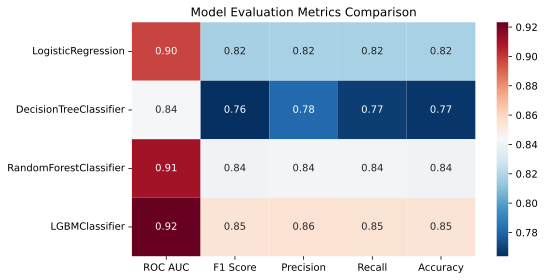

In [31]:
new_features_metrics = train_evaluate_models_cv(
    models=models,
    X=X_new_features_encoded,
    y=y_1,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                         ROC AUC  F1 Score  Precision  Recall  Accuracy
 LogisticRegression          0.0       0.0        0.0     0.0       0.0
 DecisionTreeClassifier      0.0       0.0        0.0     0.0       0.0
 RandomForestClassifier      0.0       0.0        0.0     0.0       0.0
 LGBMClassifier              0.0       0.0        0.0     0.0       0.0)

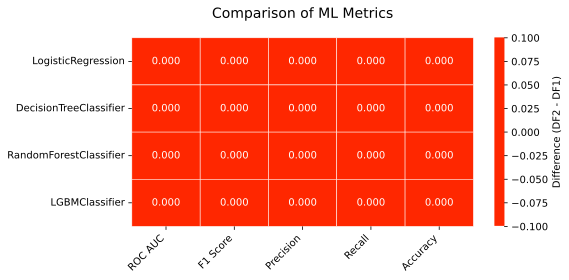

In [32]:
compare_metrics_heatmap(initial_metrics, new_features_metrics)

По всем моделям зафиксированы нулевые изменения метрик. Это означает, что добавленные признаки не оказали ни положительного, ни отрицательного влияния на предсказательную способность ни одной из рассмотренных моделей.

* **LogisticRegression**. Отсутствие изменений свидетельствует о том, что новые признаки не привносят дополнительной линейной информации, полезной для разделения классов. Вероятно, они либо линейно зависимы от уже существующих, либо их связь с целевой переменной носит нелинейный характер, который линейная модель не может уловить;

* **DecisionTreeClassifier**. Нулевой эффект ожидаем: одиночное дерево решений при стандартной настройке опирается на ограниченный набор признаков с наибольшей информативностью. Новые признаки, по всей видимости, не превзошли по качеству разбиения уже использовавшиеся;

* **RandomForestClassifier**. Ансамбль деревьев также не отреагировал на изменение признакового пространства. Это может указывать на то, что новые признаки дублируют информацию, уже извлекаемую ансамблем из исходных столбцов;

* **LGBMClassifier**. Градиентный бустинг, будучи наиболее устойчивым и чувствительным к качеству признаков алгоритмом, также не показал улучшений. Это косвенно подтверждает, что конструкция новых признаков не привнесёл принципиально новой информации сверх той, что модель уже извлекала самостоятельно.

## 3.3 Работа с дисбалансом классов

### 3.3.1 На уровне моделей

In [33]:
models_balanced = [
    ('LogisticRegression', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear', class_weight='balanced')),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=SEED, max_depth=4, class_weight='balanced')),
    ('RandomForestClassifier', RandomForestClassifier(random_state=SEED, class_weight='balanced')),
    ('LGBMClassifier', LGBMClassifier(random_state=SEED, class_weight='balanced'))
]

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

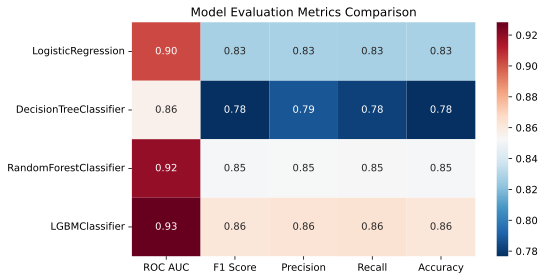

In [34]:
balanced_metrics = train_evaluate_models_cv(
    models=models_balanced,
    X=X_encoded_0,
    y=y,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.000401  0.004046   0.002962  0.004515  0.003673
 DecisionTreeClassifier -0.000057  0.002201   0.004766  0.004986  0.001255
 RandomForestClassifier -0.000865  0.001343   0.001317  0.001334  0.001344
 LGBMClassifier          0.000369  0.001123   0.001875  0.001605  0.001076)

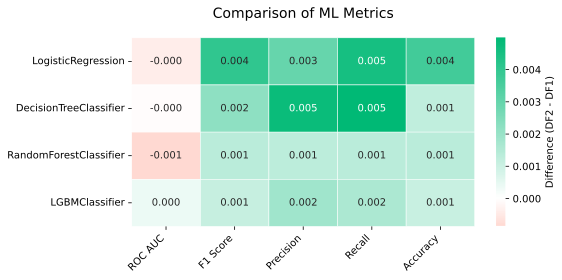

In [35]:
compare_metrics_heatmap(initial_metrics_0, balanced_metrics)

* **LogisticRegression**. F1 вырос на 0,004, Recall — на 0,0045, Precision — на 0,003. ROC AUC снизился на 0,0004 — практически незаметно. Иными словами, линейная модель стала чуть лучше улавливать положительный класс, и это не ухудшило общее ранжирование;

* **DecisionTreeClassifier**. Наибольший прирост Precision (+0,0048) и Recall (+0,005) среди всех моделей, но ROC AUC почти не изменился (−0,00006). Одиночное дерево лучше других воспользовалось новыми признаками для разбиений, улучшив точность классификации;

* **RandomForestClassifier**. Стабильный, но скромный рост F1 (+0,0013), Precision (+0,0013), Recall (+0,0013). ROC AUC снизился на 0,0009 — чуть сильнее остальных. Ансамбль получил небольшую пользу от новых признаков, но они не стали для него ключевыми;

* **LGBMClassifier**. Единственная модель, у которой выросли все метрики без исключения, включая ROC AUC (+0,0004). Приросты невелики (F1 +0,001, Recall +0,0016), но это самый «чистый» положительный результат — бустинг смог извлечь из новых признаков полезный сигнал без потерь.

### 3.3.2 Используем SMOTE

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

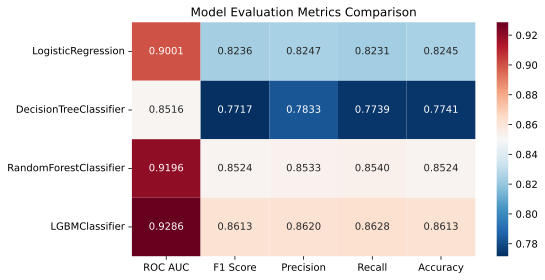

In [36]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_indices = [X.columns.get_loc(c) for c in cat_cols]

smote_params = {
    'type': 'SMOTENC',
    'categorical_features': cat_indices,
    'sampling_strategy': 1,      # миноритарный класс будет 40% от мажоритарного
    'k_neighbors': 5,
}

metrics_df = train_evaluate_models_cv_SMOTE(
    models=models,
    X=X_encoded_0,
    y=y,
    cv=cv,
    seed=SEED,
    smote_params=smote_params
)

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.002643  0.000063  -0.000170  0.000123  0.000000
 DecisionTreeClassifier -0.004945 -0.002862   0.000235 -0.003027 -0.001971
 RandomForestClassifier -0.000610  0.002342   0.002617  0.002504  0.002329
 LGBMClassifier          0.000725  0.000746   0.001103  0.001000  0.000717)

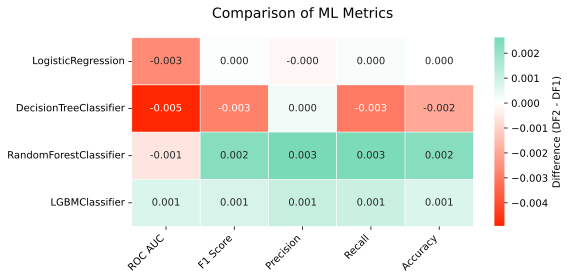

In [37]:
compare_metrics_heatmap(initial_metrics_0, metrics_df)

* **LogisticRegression**. Практически нулевой эффект: F1 вырос на 0,0001, Recall — на 0,0001, но Precision снизился на 0,0002, а Accuracy не изменилась вовсе. ROC AUC просел на 0,0026 — заметнее, чем у остальных. Линейная модель почти не отреагировала на балансировку: синтетические примеры не дали ей новой полезной информации, а лишь немного сместили разделяющую гиперплоскость в худшую сторону;

* **DecisionTreeClassifier**. Единственная модель, у которой F1, Recall и Accuracy одновременно ушли в минус (−0,0029, −0,0030 и −0,0020 соответственно). ROC AUC также упал сильнее всех — на 0,0049. Одиночное дерево оказалось наиболее уязвимым к SMOTE: синтетические примеры создали «ложные» зоны разбиения, и дерево начало переобучаться на шуме вместо реальных закономерностей;

* **RandomForestClassifier**. Наиболее выраженный положительный отклик среди всех моделей: F1 вырос на 0,0023, Precision — на 0,0026, Recall — на 0,0025, Accuracy — на 0,0023. ROC AUC снизился на 0,0006 — минимально. Ансамбль деревьев лучше других воспользовался балансировкой: усреднение множества деревьев сгладило шум от синтетических примеров, при этом дополнительный объём миноритарного класса помог улучшить детектирование целевого класса;

* **LGBMClassifier**. Единственная модель, у которой выросли все метрики без исключения, включая ROC AUC (+0,0007). Приросты невелики (F1 +0,0007, Precision +0,0011, Recall +0,0010, Accuracy +0,0007), но это самый «чистый» положительный результат — бустинг смог извлечь из балансировки полезный сигнал без потерь, корректно распределив вес синтетических примеров по итерациям.

### 3.3.3 Сравниваем метрики после балансировки на уровне модели и проведеным SMOTE

(<Figure size 800x400 with 2 Axes>,
                          ROC AUC  F1 Score  Precision    Recall  Accuracy
 LogisticRegression     -0.002242 -0.003983  -0.003132 -0.004393 -0.003673
 DecisionTreeClassifier -0.004888 -0.005064  -0.004531 -0.008013 -0.003227
 RandomForestClassifier  0.000255  0.000999   0.001300  0.001171  0.000986
 LGBMClassifier          0.000355 -0.000377  -0.000772 -0.000604 -0.000359)

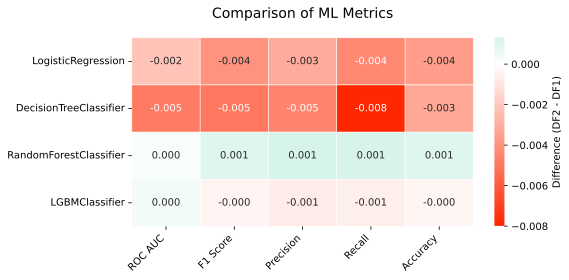

In [39]:
compare_metrics_heatmap(balanced_metrics, metrics_df)

Сравнение двух стратегий балансировки классов показало, что явная генерация синтетических примеров с помощью SMOTE не приводит к улучшению качества моделей по сравнению с более простым подходом — использованием параметра class_weight='balanced'.

Для LogisticRegression и DecisionTreeClassifier применение SMOTE привело к снижению ключевых метрик (F1, Recall, Precision), что свидетельствует о переобучении на синтетических данных. RandomForest продемонстрировал небольшой положительный эффект, однако прирост оказался незначительным. LGBMClassifier показал смешанные результаты: небольшое улучшение ROC AUC при снижении F1 и Recall.

На основании этих результатов оптимальным решением для данного датасета является использование class_weight='balanced' без применения SMOTE. Такой подход обеспечивает сопоставимое или лучшее качество при меньшей сложности пайплайна и отсутствии риска внесения дополнительного шума.

# 4. Вывод

Среди всех протестированных преобразований именно балансировка классов (через параметр class_weight='balanced') дала устойчивый положительный эффект — она обеспечила наилучшие значения ключевых метрик без риска внесения шума. Применение SMOTE, напротив, в большинстве случаев привело к снижению качества моделей, поэтому оптимальным решением для данного датасета остаётся использование взвешивания классов без генерации синтетических примеров.